# Silicon-Sensor Effects on Intra- and Extra-Focal Donuts in i Band (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-09-30
**Last Modified:** 2026-09-30
**Status:** Complete
**Keywords:** CCD, silicon sensor, conversion depth, charge diffusion, GalSim SiliconSensor, donut, intra-focal, extra-focal, Danish, i band

## Description

Estimate of how much Rubin's CCDs change the apparent blur and Zernike coefficients of
defocused donuts, and whether they do so differently intra- and extra-focally. At a
given detector position, intra-focal photons are still converging, while extra-focal
photons are diverging. A photon that converts at depth z in the silicon therefore lands
displaced inward on one side of focus and outward on the other.

Method:
1. Photons are traced with batoid through the design prescription `LSST_i.yaml`, with
   the whole camera pistoned ±1.5 mm as in full-array-mode (FAM) data. Each photon
   gets a wavelength drawn from the LSST i bandpass (flat photon spectrum) and an
   atmospheric deflection drawn from a 0.7″ FWHM von Kármán PSF (L0 = 20 m), applied
   by per-ray kick.
2. The photons are accumulated with GalSim's `SiliconSensor`: wavelength-dependent
   conversion depth, lateral travel to that depth along the incidence direction, and
   charge diffusion. Brighter-fatter is effectively off (strength 10⁻⁶ of nominal).
   Both the ITL and e2v sensor models are used.
3. GalSim moves the photon along its given `dxdz`/`dydz` without refracting at the
   silicon surface. Three cases are therefore compared:
   - Snell-refracted directions (physical);
   - unrefracted air directions (what happens if batoid's directions are passed
     unchanged);
   - normal incidence (diffusion only).
4. Each stamp is fitted with Danish (geometric donut model plus Kolmogorov kernel,
   reference TA from `zernikeTA` of the defocused i-band optic at the bandpass
   effective wavelength).

The optics here are geometric. Diffraction (`optics_fresnel_rubin_seeing_v1.ipynb`)
and the sensor act at different stages and are treated separately.

**Output:** figures in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/fresnel_donuts.md`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-30 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Scales: absorption length and in-silicon angles](#scales)
5. [Photons and sensor images](#images)
6. [Danish fits](#fits)
7. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
prescription = 'LSST_i.yaml'
bandpass_file = 'LSST_i.dat'          # GalSim share/bandpasses
defocus_values = {'intra': -1.5e-3, 'extra': +1.5e-3}   # m, camera piston (FAM)
seeing_fwhm = 0.7                     # arcsec, von Karman FWHM at the effective wavelength
outer_scale = 20.0                    # m
n_photons = 20_000_000                # photons launched per side
sensors = ['lsst_itl_50_8', 'lsst_e2v_50_8']
bf_strength = 1e-6                    # brighter-fatter strength relative to nominal (~off)
pixel_size = 10e-6                    # m
npix_stamp = 199
output_date = '20260930'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'common').is_dir())))
from common.utils import setup_plotting, repo_root

root = repo_root()
sys.path.insert(0, str(root / 'optics' / 'code' / 'fresnel'))
import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import donut_seeing as ds
import donut_sensor as dsn
import batoid
import galsim

setup_plotting()
output_dir = root / 'optics' / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
bandpass = galsim.Bandpass(bandpass_file, 'nm')
w_eff = bandpass.effective_wavelength * 1e-9
print(f'batoid {batoid.__version__} | galsim {galsim.__version__}')
print(f'i band: {bandpass.blue_limit:.0f}-{bandpass.red_limit:.0f} nm, effective wavelength '
      f'{w_eff*1e9:.1f} nm')

batoid 0.8.1 | galsim 2.8.5
i band: 676-833 nm, effective wavelength 754.6 nm


<a id='functions'></a>
## Helper Functions

In [3]:
def radial(img, pixel):
    # Azimuthal profile of an odd-sized centred image: mean pixel value per
    # one-pixel-wide annulus (unit total flux, 1/m^2); returns (r [m], profile).
    # Flux/annulus-area would imprint the ~4% ring-to-ring variation in the
    # number of pixel centres per annulus as spurious ringing.
    return fd.pixel_radial_profile(img, pixel)

<a id='scales'></a>
## 1. Scales: absorption length and in-silicon angles

The marginal ray reaches the detector at ~23° in air. Silicon's index (n ≈ 3.7 in i
band) refracts it to ~6°. A photon converting at depth z therefore moves laterally by
z·tan θ_Si: inward for intra-focal (converging) photons and outward for extra-focal
(diverging) photons. The displacement is proportional to the ray angle, which grows
with pupil radius, so its mean behaves like a small common focus shift, and its spread
like a radial blur.

In [4]:
abs_tab = np.loadtxt(Path(galsim.meta_data.share_dir) / 'sensors' / 'abs_length.dat', skiprows=1)
telescope = batoid.Optic.fromYaml(prescription)
optics = {side: fd.shift_camera(telescope, dz) for side, dz in defocus_values.items()}
atm = ds.vonkarman(seeing_fwhm, w_eff, outer_scale)
centers = {side: fd.chief_ray_point(o, w_eff) for side, o in optics.items()}

t0 = time.perf_counter()
photons = {side: dsn.trace_photons(o, n_photons, bandpass, atm, seed=5)
           for side, o in optics.items()}
print(f'traced {n_photons} photons per side in {time.perf_counter()-t0:.0f} s; '
      f'{len(photons["extra"]["x"])} reach the detector')

ph = photons['extra']
wl = ph['wavelength']
absl = np.interp(wl, abs_tab[:, 0], abs_tab[:, 1])
tan_air = np.hypot(ph['dxdz'], ph['dydz'])
dx_si, dy_si = dsn.refract_into_silicon(ph['dxdz'], ph['dydz'], wl)
tan_si = np.hypot(dx_si, dy_si)
print(f'absorption length over the i-band photons: median {np.median(absl):.1f} um, '
      f'10-90% {np.percentile(absl, 10):.1f}-{np.percentile(absl, 90):.1f} um (GalSim table)')
print(f'incidence angle in air: {np.degrees(np.arctan(tan_air.min())):.1f}-'
      f'{np.degrees(np.arctan(tan_air.max())):.1f} deg; in silicon: '
      f'{np.degrees(np.arctan(tan_si.min())):.2f}-{np.degrees(np.arctan(tan_si.max())):.2f} deg')
print(f'mean lateral travel to the conversion depth: refracted '
      f'{np.mean(absl * tan_si):.2f} um, unrefracted {np.mean(absl * tan_air):.2f} um')
for side in optics:
    print(f'{side}: mean radial shift for conversion at 10 um depth: refracted '
          f'{dsn.mean_radial_shift(photons[side], centers[side], 10)*1e6:+.3f} um, air '
          f'{dsn.mean_radial_shift(photons[side], centers[side], 10, "air")*1e6:+.3f} um '
          f'(positive = outward)')

traced 20000000 photons per side in 53 s; 9824590 reach the detector


absorption length over the i-band photons: median 8.1 um, 10-90% 5.4-12.7 um (GalSim table)
incidence angle in air: 14.3-23.9 deg; in silicon: 3.73-6.35 deg
mean lateral travel to the conversion depth: refracted 0.78 um, unrefracted 3.06 um
intra: mean radial shift for conversion at 10 um depth: refracted -0.895 um, air -3.537 um (positive = outward)


extra: mean radial shift for conversion at 10 um depth: refracted +0.894 um, air +3.536 um (positive = outward)


<a id='images'></a>
## 2. Photons and sensor images

The same photons are accumulated eight ways for each side of focus: ideal pixels
(positions binned, no silicon), and for each of the two sensor models, normal
incidence, refracted directions and unrefracted air directions. Using identical photons
means the differences between cases are not affected by independent photon noise.

14 stamps in 8 s


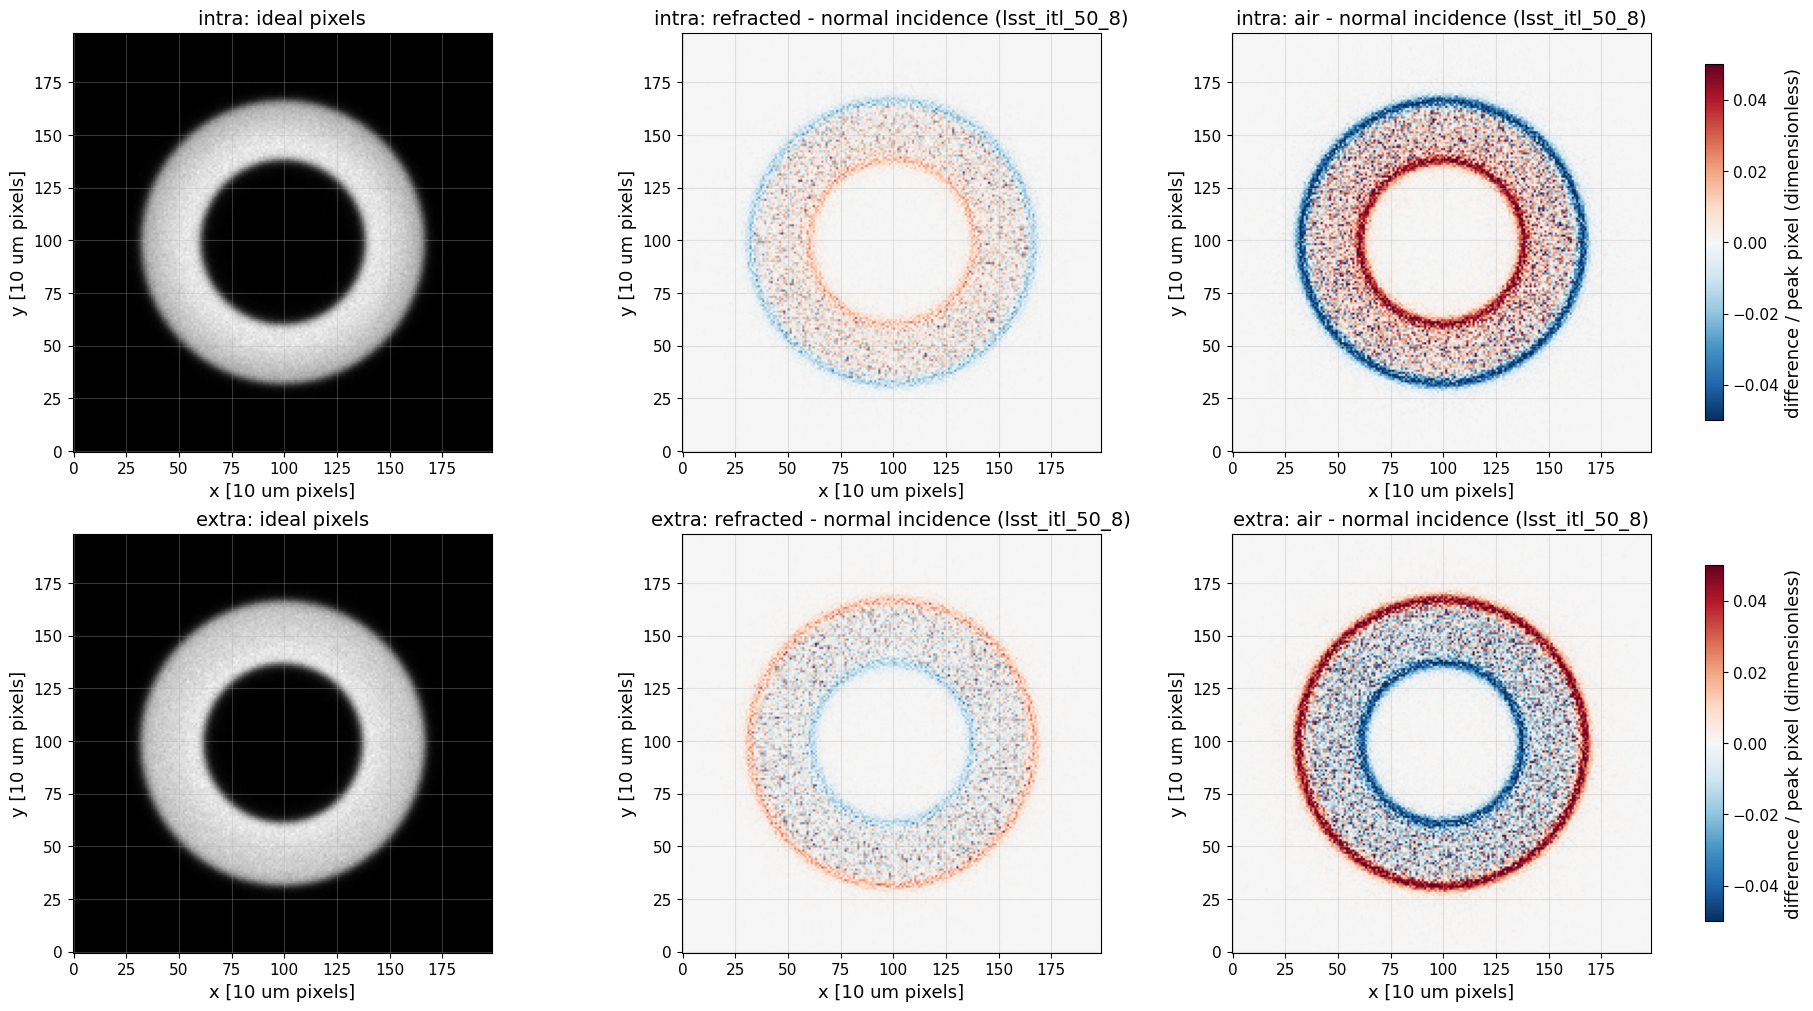

In [5]:
stamps = {}
t0 = time.perf_counter()
for side in optics:
    stamps[(side, 'ideal pixels')] = dsn.sensor_image(photons[side], centers[side], npix_stamp)
    for name in sensors:
        for mode in ['normal', 'refracted', 'air']:
            sen = galsim.SiliconSensor(name=name, strength=bf_strength,
                                       rng=galsim.BaseDeviate(7))
            stamps[(side, f'{name}, {mode}')] = dsn.sensor_image(
                photons[side], centers[side], npix_stamp, sensor=sen, angles=mode)
print(f'{len(stamps)} stamps in {time.perf_counter()-t0:.0f} s')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, side in enumerate(['intra', 'extra']):
    ref = stamps[(side, 'ideal pixels')]
    axes[row, 0].imshow(ref, origin='lower', cmap='gray')
    axes[row, 0].set_title(f'{side}: ideal pixels')
    for a, mode in zip(axes[row, 1:], ['refracted', 'air']):
        img = stamps[(side, f'{sensors[0]}, {mode}')]
        nrm = stamps[(side, f'{sensors[0]}, normal')]
        im = a.imshow((img - nrm) / nrm.max(), origin='lower', cmap='RdBu_r',
                      vmin=-0.05, vmax=0.05)
        a.set_title(f'{side}: {mode} - normal incidence ({sensors[0]})')
    fig.colorbar(im, ax=axes[row, 1:], label='difference / peak pixel (dimensionless)',
                 shrink=0.85)
for a in axes.ravel():
    a.set_xlabel('x [10 um pixels]'); a.set_ylabel('y [10 um pixels]')
fig.savefig(output_dir / f'optics_fresnel_sensor_iband_stamps_{output_date}.png', dpi=110)

<a id='fits'></a>
## 3. Danish fits

Fitted Kolmogorov FWHM and Zernike offsets (Z4–Z22 free) relative to the TA of the
defocused i-band optic at the effective wavelength.

In [6]:
z_refs = {side: ds.reference_zernikes(o, w_eff) for side, o in optics.items()}
fits = {key: ds.danish_fit(img, z_refs[key[0]]) for key, img in stamps.items()}
cases = [k for (s, k) in stamps if s == 'intra']
hdr = (f"{'case':30s} {'FWHM i [as]':>11s} {'FWHM e [as]':>11s} {'i - e [as]':>10s} "
       f"{'dZ4 i [nm]':>10s} {'dZ4 e [nm]':>10s} {'mean dZ4 [nm]':>13s} {'dZ11 i':>7s} {'dZ11 e':>7s}")
print(hdr); print('-' * len(hdr))
for k in cases:
    fi, fe = fits[('intra', k)], fits[('extra', k)]
    print(f"{k:30s} {fi['fwhm']:11.4f} {fe['fwhm']:11.4f} {fi['fwhm'] - fe['fwhm']:10.4f} "
          f"{fi['z_fit'][0]*1e9:10.2f} {fe['z_fit'][0]*1e9:10.2f} "
          f"{0.5*(fi['z_fit'][0] + fe['z_fit'][0])*1e9:13.2f} "
          f"{fi['z_fit'][7]*1e9:7.2f} {fe['z_fit'][7]*1e9:7.2f}")
print('FWHM: fitted Kolmogorov FWHM; dZ: fitted offset from the reference TA, nm of wavefront '
      '(Noll); mean dZ4: average of intra and extra, i.e. the apparent focus offset a '
      'combined intra+extra estimate would report')

case                           FWHM i [as] FWHM e [as] i - e [as] dZ4 i [nm] dZ4 e [nm] mean dZ4 [nm]  dZ11 i  dZ11 e
---------------------------------------------------------------------------------------------------------------------
ideal pixels                        0.7611      0.7615    -0.0005      -2.82       1.75         -0.54   -0.58    2.08
lsst_itl_50_8, normal               0.7843      0.7842     0.0001      -2.77       2.05         -0.36   -0.42    1.96
lsst_itl_50_8, refracted            0.7854      0.7851     0.0003      31.62      36.42         34.02   -0.43    1.98
lsst_itl_50_8, air                  0.7968      0.7951     0.0017     126.60     128.32        127.46   -0.57    1.92
lsst_e2v_50_8, normal               0.7838      0.7837     0.0001      -2.75       2.06         -0.34   -0.44    1.96
lsst_e2v_50_8, refracted            0.7849      0.7845     0.0004      31.63      36.42         34.02   -0.43    1.98
lsst_e2v_50_8, air                  0.7963      0.7947  

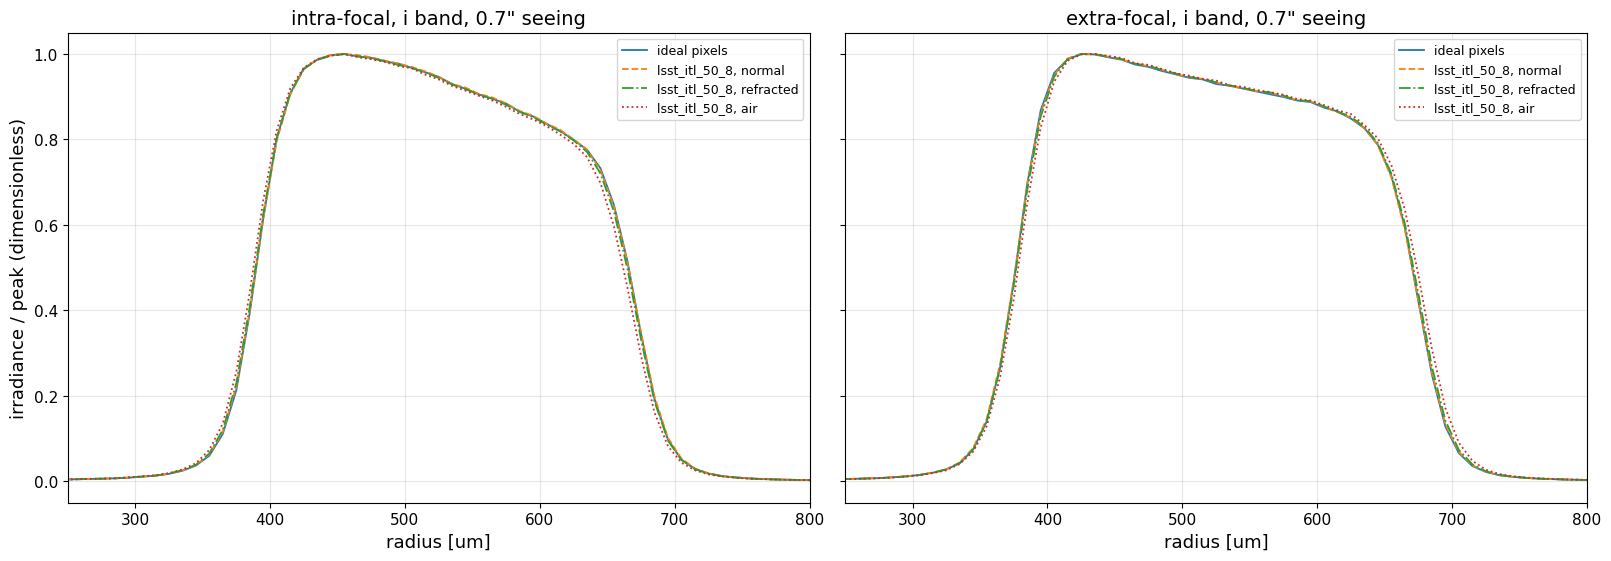

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for a, side in zip(axes, ['intra', 'extra']):
    for k, ls in [('ideal pixels', '-'), (f'{sensors[0]}, normal', '--'),
                  (f'{sensors[0]}, refracted', '-.'), (f'{sensors[0]}, air', ':')]:
        r, p = radial(stamps[(side, k)], pixel_size)
        a.plot(r * 1e6, p / p.max(), ls, lw=1.3, label=k)
    a.set_title(f'{side}-focal, i band, 0.7" seeing')
    a.set_xlabel('radius [um]'); a.set_xlim(250, 800)
    a.legend(fontsize=9)
axes[0].set_ylabel('irradiance / peak (dimensionless)')
fig.savefig(output_dir / f'optics_fresnel_sensor_iband_profiles_{output_date}.png', dpi=110)

<a id='conclusions'></a>
## 4. Conclusions

i band (676–833 nm, effective wavelength 754.6 nm), on axis, design prescription
`LSST_i.yaml`, camera piston ±1.5 mm, 0.7″ von Kármán seeing, geometric optics.
Numbers are from this run.

- **The sensor does not produce an intra/extra blur difference.** Fitted Kolmogorov
  FWHM, intra − extra (arcsec):

  | Case | Intra − extra |
  |---|---|
  | Ideal pixels | −0.0005 |
  | Normal incidence (diffusion only) | +0.0001 |
  | Refracted incidence | +0.0003 to +0.0004 |
  | Unrefracted air angles | +0.0016 to +0.0017 |

  ITL and e2v sensors agree to 0.0005″. The observed effect is ~0.1″ (intra larger),
  about 300 times bigger than the refracted-incidence case.
- **Charge diffusion** raises the fitted FWHM by 0.023″ (0.761″ → 0.784″), equally on
  both sides.
- **Travel to the conversion depth** adds only 0.001″ more. Silicon refracts the 14–24°
  air incidence angles to 3.7–6.4°, and the median absorption length is 8.1 µm, so the
  mean lateral travel is 0.78 µm.
- **The sensor's real signature is an apparent focus offset.** Conversion at depth
  moves intra-focal photons inward and extra-focal photons outward. That is the same
  as a detector surface slightly deeper than the batoid model's, which Danish reads as
  a common Z4 offset of +34.0 nm of wavefront on both sides (+31.6 intra, +36.4
  extra), with Z11 unchanged.
  - It scales with absorption length, so it is strongly band dependent: smaller in r
    and g, much larger in z and y.
  - It is not modelled by a batoid detector plane at the silicon surface.
- **If batoid's air directions were passed to GalSim without refraction** (GalSim does
  not refract), the lateral travel would be 4× too large: a +127 nm Z4 offset and a
  spurious +0.0017″ intra − extra FWHM difference. Any CCD simulation of this kind
  must refract the photon directions first.
- **Caveats.** GalSim's absorption-length table is for room temperature; at the
  sensors' operating temperature (about −100 °C) absorption lengths in i band are
  longer, so the Z4 offset is a lower estimate. Brighter-fatter was switched off; at
  realistic donut surface brightness (≲10³ electrons per pixel) it is expected to be
  small and symmetric.
